# 05 — Prompt Variance

Systematic evaluation of how prompt design affects **Llama-3.3-70b** credit risk predictions.
Mirrors the same three-phase rigour used in model selection (04a/04b/04c).

**Fixed across all phases:** model (Llama-3.3-70b via NVIDIA NIM), same evaluation metrics  
**Varied:** system prompt framing, user prompt structure, presence of borrower description

---

## Structure

| Phase | Equivalent | What it does |
|-------|------------|--------------|
| 1 — Comparison | 04a | Run all 7 prompt variants on the evaluation sample; pick the best by Charged Off F1 |
| 2 — Consistency | 04b | Run the winning variant 3× on the same sample; measure stability |
| 3 — Robustness | 04c | Run the winning variant on a new held-out batch; check generalisation |
| 4 — Qualitative | — | LLM-judge characterisation of each variant's reasoning fingerprint |
| 4b — Pairwise Judge | — | Head-to-head tournament: top-3 variants on disagreement loans (CME295 Lec 7) |
| 5 — Description Impact | — | Re-run all variants with borrower descriptions; compare to Phase 1 baseline |

## Prompt variants tested in Phase 1

| # | Name | What changes | CME295 inspiration |
|---|------|--------------|-------------------|
| 0 | `baseline` | Current production prompt — control group | — |
| 1 | `conservative` | Role reframed as risk-averse underwriter; bias toward flagging defaults | — |
| 2 | `chain_of_thought` | Step-by-step reasoning through 7 risk signals before predicting | Lec 3 (CoT) + Lec 6 (test-time compute: smaller batches = more tokens per loan) |
| 3 | `few_shot` | 6 balanced examples (3 CO + 3 FP) from held-out batch prepended | Lec 1–2 (in-context learning) |
| 4 | `top_features_only` | Only the 8 most important features (by XGBoost importance) passed in | — |
| 5 | `structured_4factor` | Explicit 4-factor evaluation framework in system prompt | — |
| 6 | `self_verify` | Initial prediction → adversarial challenge → committed answer | Lec 5 (self-critique / RLHF loop) |

## Setup

In [ ]:
import sys
sys.path.insert(0, '..')

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from llm_utils import (
    load_llm_sample,
    sample_new_batch,
    run_llm_experiment,
    evaluate_predictions,
    build_system_prompt,
    build_user_prompt,
    build_few_shot_examples,
    format_loan_features,
    FEATURE_DESCRIPTIONS,
    RESULTS_DIR,
    DATA_DIR,
)

API_PROVIDER       = 'nvidia'
MODEL_NAME         = 'meta/llama-3.3-70b-instruct'
MODEL_LABEL        = 'Llama-3.3-70b'
N_CONSISTENCY_RUNS = 3

## Define Prompt Variants

Seven variants test different prompt engineering strategies. Variants 2, 3, and 6 are directly inspired
by concepts from **Stanford CME295 — Transformers & Large Language Models**:

- **`chain_of_thought`** (Variant 2) — CME295 Lecture 3 (chain-of-thought prompting) + Lecture 6
  (test-time compute): sequential 7-signal reasoning protocol. Runs with `batch_size=10` so
  each loan gets more token budget per API call.
- **`few_shot`** (Variant 3) — CME295 Lectures 1–2 (in-context learning): 6 balanced examples
  (3 CO + 3 FP) drawn from the held-out `04c_new_batch_sample.csv` to anchor the label distribution.
- **`self_verify`** (Variant 6) — CME295 Lecture 5 (self-critique / RLHF): predict → then argue the
  *opposite* conclusion (devil's advocate) → then commit. Forces the model to stress-test its own
  reasoning before locking in a prediction, reducing confirmation bias in a single forward pass.

In [ ]:
TOP_FEATURES = [
    'int_rate', 'sub_grade', 'dti', 'revol_util',
    'annual_inc', 'installment', 'loan_amnt', 'revol_bal',
]

def format_top_features(row):
    lines = []
    for feat in TOP_FEATURES:
        if feat in row and pd.notna(row[feat]):
            label = FEATURE_DESCRIPTIONS.get(feat, feat)
            lines.append(f"- {label}: {row[feat]}")
    return "\n".join(lines)


# ── Shared domain knowledge block — embedded in every system prompt ───────────
_DOMAIN_BASE = (
    "You are a senior credit risk analyst evaluating LendingClub loan applications "
    "(2012–2014 vintage). Predict: Fully Paid (1) or Charged Off / default (0).\n\n"
    "Risk signal reference:\n"
    "  • Grade/sub-grade: A1 = safest → G5 = riskiest | E–G: >30% default rate | A–B: <7%\n"
    "  • Interest rate: >18% = high-risk tier\n"
    "  • DTI: <15% healthy | 15–25% moderate | 25–35% elevated | >35% critical\n"
    "  • Revolving utilisation: >80% = credit dependency\n"
    "  • Purpose risk (high → low): small_business, medical, moving → other → "
    "debt_consolidation, credit_card\n"
    "  • Derogatory records / bankruptcies: strong negative weight\n"
    "  • Unverified income: treat stated income with caution\n\n"
    "Calibration: sample is balanced — ~50% defaulted. Do NOT assume most will repay."
)

# ── Shared output format suffix ───────────────────────────────────────────────
_OUTPUT_FMT = (
    '\n\nRespond ONLY with valid JSON:\n'
    '{"prediction": <1 or 0>, "reasoning": "<explanation>"}\n'
    'prediction: 1 = Fully Paid, 0 = Charged Off'
)


PROMPT_VARIANTS = [
    # ── 0: Baseline ──────────────────────────────────────────────────────────
    {
        "name": "baseline",
        "description": "Full domain knowledge, balanced analyst — control group",
        "system_prompt": build_system_prompt(),
        "user_prompt_fn": lambda row: build_user_prompt(row, include_desc=False),
    },

    # ── 1: Conservative ──────────────────────────────────────────────────────
    {
        "name": "conservative",
        "description": "Loss-prevention underwriter: err toward CO when evidence is mixed",
        "system_prompt": (
            _DOMAIN_BASE
            + "\n\nUnderwriting mandate: the cost of approving a loan that defaults is "
            "significantly higher than the cost of declining a borderline application. "
            "When signals are mixed or ambiguous, err on the side of caution — predict "
            "Charged Off. Only predict Fully Paid when repayment signals clearly dominate "
            "across multiple independent factors."
            + _OUTPUT_FMT
            + "\nreasoning: state which risk factors drove caution, or why repayment signals dominate"
        ),
        "user_prompt_fn": lambda row: build_user_prompt(row, include_desc=False),
    },

    # ── 2: Chain of thought ──────────────────────────────────────────────────
    # CME295 Lec 3 (CoT prompting) + Lec 6 (test-time scaling):
    # explicit 7-step protocol forces deliberate feature-by-feature analysis.
    # Runs with batch_size=10 in Phase 1 so each loan gets more tokens per call.
    {
        "name": "chain_of_thought",
        "description": "Sequential 7-signal reasoning protocol before predicting (smaller batches = more tokens)",
        "system_prompt": (
            _DOMAIN_BASE
            + "\n\nReasoning protocol — work through each signal explicitly before concluding:\n"
            "  1) Grade/sub-grade — what risk tier does this place the borrower in?\n"
            "  2) Interest rate — does it confirm the grade signal?\n"
            "  3) DTI — can the borrower absorb the monthly payment?\n"
            "  4) Revolving utilisation — credit-dependent or financially disciplined?\n"
            "  5) Loan purpose — productive use or distress borrowing?\n"
            "  6) Income and verification — sufficient capacity and reliable source?\n"
            "  7) Derogatory records — any hard negative signals?\n"
            "  Synthesis — weigh positives against negatives and commit to a prediction."
            + _OUTPUT_FMT
            + "\nreasoning: 3-4 sentences summarising your analysis — dominant signals, mitigating factors, conclusion"
        ),
        "user_prompt_fn": lambda row: (
            "Work through the 7-signal protocol and predict the outcome for this loan:\n\n"
            + format_loan_features(row, include_desc=False)
        ),
    },

    # ── 3: Few-shot ──────────────────────────────────────────────────────────
    # CME295 Lec 1-2 (in-context learning): 6 balanced examples (3 CO + 3 FP)
    # drawn from the separate 04c_new_batch_sample.csv to avoid eval-set contamination.
    {
        "name": "few_shot",
        "description": "6 balanced examples (3 CO + 3 FP) from held-out batch — in-context learning",
        "system_prompt": build_system_prompt(),
        "user_prompt_fn": None,  # set below — skipped if source CSV unavailable
    },

    # ── 4: Top features only ─────────────────────────────────────────────────
    {
        "name": "top_features_only",
        "description": "Focus on the 8 most predictive features (by XGBoost importance)",
        "system_prompt": (
            "You are a quantitative credit risk analyst evaluating LendingClub loan "
            "applications (2012–2014 vintage). You work exclusively from the 8 features "
            "that carry the most predictive weight for default, ranked by XGBoost importance:\n\n"
            "  1. Interest rate — highest weight; the platform's own risk price signal\n"
            "  2. Sub-grade — granular risk tier (A1 = safest, G5 = riskiest; E–G default >30%)\n"
            "  3. DTI — repayment capacity; >35% is a critical default signal\n"
            "  4. Revolving utilisation — liquidity health; >80% = credit-dependent borrower\n"
            "  5. Annual income — absolute capacity; evaluate relative to installment burden\n"
            "  6. Monthly installment — high relative to income signals overextension\n"
            "  7. Loan amount — amplifies risk when grade and rate signals are negative\n"
            "  8. Revolving balance — high balance + high utilisation = distressed credit profile\n\n"
            "Trust the data — do not infer information not given. Ignore features outside this list.\n\n"
            "Calibration: sample is balanced — ~50% defaulted. Do NOT assume most will repay."
            + _OUTPUT_FMT
            + "\nreasoning: cite the 2-3 of these 8 features that most decisively drove your prediction"
        ),
        "user_prompt_fn": lambda row: (
            "Predict the outcome using the 8 key features:\n\n"
            + format_top_features(row)
        ),
    },

    # ── 5: Structured 4-factor ───────────────────────────────────────────────
    {
        "name": "structured_4factor",
        "description": "4-factor scorecard: repayment capacity, debt burden, credit quality, loan fit",
        "system_prompt": (
            "You are a credit risk analyst using a structured 4-factor scorecard to evaluate "
            "LendingClub loan applications (2012–2014 vintage).\n\n"
            "FACTOR 1 — Repayment Capacity\n"
            "  • Installment-to-income ratio: <8% = comfortable | 8–15% = moderate | >15% = stretched\n"
            "  • Income verification: Source / Not Verified = weaker signal than Verified\n\n"
            "FACTOR 2 — Debt Burden\n"
            "  • DTI: <15% = healthy | 15–25% = moderate | 25–35% = elevated | >35% = critical\n"
            "  • Revolving utilisation: <50% = healthy | 50–80% = moderate | >80% = distressed\n\n"
            "FACTOR 3 — Credit Quality\n"
            "  • Grade/sub-grade: A–B = investment grade (<7% default) | C–D = speculative |\n"
            "    E–G = distressed (>30% default)\n"
            "  • Interest rate as the platform's implied risk premium (>18% = distressed tier)\n"
            "  • Derogatory public records or bankruptcies: any = automatic risk flag\n\n"
            "FACTOR 4 — Loan Characteristics\n"
            "  • Purpose: debt_consolidation, credit_card = lower risk |\n"
            "    small_business, medical, moving = elevated risk\n"
            "  • Term: 60-month loans carry higher default rates than 36-month\n"
            "  • Loan size: large amounts on weak-grade applicants amplify default risk\n\n"
            "Scoring rule: assess each factor independently, then synthesise. "
            "A loan that fails 2+ factors is high-risk. "
            "A loan strong on Factors 1 and 3 is typically safe.\n\n"
            "Calibration: sample is balanced — ~50% defaulted."
            + _OUTPUT_FMT
            + "\nreasoning: identify which factors drove the decision and the key metric(s) within each"
        ),
        "user_prompt_fn": lambda row: build_user_prompt(row, include_desc=False),
    },

    # ── 6: Self-verify ───────────────────────────────────────────────────────
    # CME295 Lec 5 (RLHF / self-critique): the model predicts, then deliberately argues the
    # OPPOSITE conclusion (devil's advocate), then decides whether to update or confirm.
    # This reduces confirmation bias without a second API call — all three phases in one pass.
    {
        "name": "self_verify",
        "description": "Predict → adversarial challenge → committed answer (self-critique, CME295 Lec 5)",
        "system_prompt": (
            _DOMAIN_BASE
            + "\n\nReasoning protocol — complete ALL THREE phases before committing:\n"
            "  Phase 1 — Initial assessment: form your first judgment from the loan features.\n"
            "  Phase 2 — Devil's advocate: actively argue the OPPOSITE conclusion. What evidence "
            "supports the other outcome? What might your Phase 1 assessment have overlooked or "
            "over-weighted? Be specific — name actual feature values.\n"
            "  Phase 3 — Commit: weigh Phase 1 vs Phase 2. If Phase 2 raised compelling "
            "counter-evidence, update your prediction. Otherwise confirm it.\n\n"
            "This protocol reduces confirmation bias by forcing explicit adversarial stress-testing "
            "before locking in a final answer."
            + '\n\nRespond ONLY with valid JSON:\n'
            '{"prediction": <1 or 0>, "initial": "<Phase 1 in one sentence>", '
            '"challenge": "<Phase 2 counter-argument in one sentence>", '
            '"reasoning": "<Phase 3 final synthesis and commitment in one sentence>"}\n'
            'prediction: 1 = Fully Paid, 0 = Charged Off'
        ),
        "user_prompt_fn": lambda row: build_user_prompt(row, include_desc=False),
    },
]


# ── Few-shot: load 6 balanced examples from 04c_new_batch_sample.csv ─────────
# Uses the HELD-OUT batch (separate from eval sample) to avoid data leakage.
# 3 CO + 3 FP examples, shuffled, with ground-truth labels shown to the LLM.
_fewshot_path = os.path.join(DATA_DIR, '04c_new_batch_sample.csv')
_fewshot_variant = next((v for v in PROMPT_VARIANTS if v['name'] == 'few_shot'), None)

try:
    _src = pd.read_csv(_fewshot_path)
    _co_ex = _src[_src['loan_status'] == 0].sample(3, random_state=42)
    _fp_ex = _src[_src['loan_status'] == 1].sample(3, random_state=42)
    _fewshot_df = pd.concat([_co_ex, _fp_ex]).sample(frac=1, random_state=0).reset_index(drop=True)

    _fewshot_lines = []
    for _, _ex in _fewshot_df.iterrows():
        _lbl = "Fully Paid (1)" if int(_ex['loan_status']) == 1 else "Charged Off (0)"
        _fewshot_lines.append(
            f"[Example]\n"
            f"{format_loan_features(_ex, include_desc=False)}\n"
            f"Outcome: {_lbl}"
        )
    _fewshot_text = "\n\n---\n\n".join(_fewshot_lines)

    if _fewshot_variant is not None:
        _fewshot_variant["user_prompt_fn"] = lambda row: (
            "Here are 6 past loan outcomes (3 Fully Paid, 3 Charged Off) to calibrate your judgment:\n\n"
            + _fewshot_text
            + "\n\n---\n\nNow predict the outcome for this new loan application:\n\n"
            + format_loan_features(row, include_desc=False)
        )
    print(f"few_shot variant ready — {len(_fewshot_df)} examples from 04c_new_batch_sample.csv "
          f"({(_fewshot_df['loan_status']==0).sum()} CO + {(_fewshot_df['loan_status']==1).sum()} FP).")
except FileNotFoundError:
    print("WARNING: 04c_new_batch_sample.csv not found — skipping few_shot variant.")
    PROMPT_VARIANTS = [v for v in PROMPT_VARIANTS if v["name"] != "few_shot"]

print(f"\n{len(PROMPT_VARIANTS)} prompt variants active:")
for v in PROMPT_VARIANTS:
    print(f"  [{v['name']}]  {v['description']}")

## Load Data & XGBoost Baseline

In [3]:
llm_sample = load_llm_sample()
y_true = llm_sample['loan_status'].values

print(f'Sample: {len(llm_sample)} loans | '
      f'Fully Paid: {(y_true==1).sum()} | Charged Off: {(y_true==0).sum()}')


Sample: 100 loans | Fully Paid: 85 | Charged Off: 15


---
## Phase 1 — Comparison
*Which prompt variant performs best on the 100-loan evaluation sample?*

All variants use **Llama-3.3-70b via NVIDIA NIM**, no borrower description. Experiments run sequentially.

In [ ]:
phase1_results = {}
phase1_failed  = []

for variant in PROMPT_VARIANTS:
    name = variant["name"]
    print(f"\n{'='*60}\nVariant: {name}\n{'='*60}")

    # CME295 Lec 6 (test-time scaling): chain_of_thought uses batch_size=10
    # so each API call covers only 10 loans, giving the model more token budget
    # per loan to elaborate its 7-step reasoning chain. All other variants use
    # batch_size=0 (all loans in one call) for speed.
    batch_sz = 10 if name == 'chain_of_thought' else 0

    try:
        result = run_llm_experiment(
            llm_sample,
            api_provider=API_PROVIDER,
            model_name=MODEL_NAME,
            include_desc=False,
            label=f"{MODEL_LABEL} | {name}",
            with_logprobs=False,
            batch_size=batch_sz,
            system_prompt=variant["system_prompt"],
            user_prompt_fn=variant["user_prompt_fn"],
        )
        phase1_results[name] = result
    except Exception as e:
        print(f"*** FAILED [{name}]: {e} ***")
        phase1_failed.append((name, str(e)))

print(f"\nPhase 1 done: {len(phase1_results)} succeeded, {len(phase1_failed)} failed")

In [5]:
p1_rows = []
for v in PROMPT_VARIANTS:
    name = v['name']
    if name in phase1_results:
        p1_rows.append({'variant': name, 'description': v['description'], **phase1_results[name]['metrics']})

phase1_summary = pd.DataFrame(p1_rows).set_index('variant')
display_cols = ['accuracy', 'auc', 'precision_charged_off', 'recall_charged_off', 'f1_charged_off', 'n_valid']
print(phase1_summary[display_cols].to_string(float_format='{:.3f}'.format))


                    accuracy   auc  precision_charged_off  recall_charged_off  f1_charged_off  n_valid
variant                                                                                               
baseline               0.550  None                  0.200               0.667           0.308      100
conservative           0.550  None                  0.212               0.733           0.328      100
chain_of_thought       0.580  None                  0.200               0.600           0.300      100
top_features_only      0.570  None                  0.241               0.867           0.377      100
structured_4factor     0.620  None                  0.220               0.600           0.321      100


In [ ]:
plot_df = phase1_summary.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Phase 1 — Prompt Variant Comparison (Llama-3.3-70b, no desc)', fontsize=13)
colors = plt.cm.tab10.colors

for ax, (metric, title) in zip(axes, [
    ('accuracy',       'Overall Accuracy'),
    ('f1_charged_off', 'Charged Off F1  (primary metric)'),
]):
    vals = plot_df[metric].apply(
        lambda x: 0.0 if (x is None or (isinstance(x, float) and np.isnan(x))) else float(x)
    )
    bars = ax.barh(plot_df['variant'], vals, color=colors[:len(plot_df)])
    for bar, val in zip(bars, plot_df[metric]):
        if val is not None and not (isinstance(val, float) and np.isnan(val)):
            ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                    f'{val:.3f}', va='center', fontsize=8)
    ax.set_title(title)
    ax.set_xlim(0, 1.1)

# AUC omitted: with_logprobs=False means all AUC values are None — showing zero bars is misleading
plt.tight_layout()
plt.show()

In [7]:
# Winner = highest Charged Off F1 (the metric that matters most for credit risk)
winner_name = max(
    phase1_results,
    key=lambda name: phase1_results[name]["metrics"]["f1_charged_off"] or 0
)
winner_variant = next(v for v in PROMPT_VARIANTS if v["name"] == winner_name)

print(f"Winner: [{winner_name}]")
print(f"Description: {winner_variant['description']}")
print(f"Charged Off F1: {phase1_results[winner_name]['metrics']['f1_charged_off']:.3f}")
print(f"Accuracy:       {phase1_results[winner_name]['metrics']['accuracy']:.3f}")
print(f"\nThis variant will be used for Phase 2 (consistency) and Phase 3 (robustness).")

Winner: [top_features_only]
Description: Only the 8 most important features by XGBoost importance are passed in
Charged Off F1: 0.377
Accuracy:       0.570

This variant will be used for Phase 2 (consistency) and Phase 3 (robustness).


---
## Phase 2 — Consistency
*Is the winning prompt stable, or does it flip predictions between runs?*

Same 100-loan sample, same winning prompt, run 3 times. We measure per-loan flip rate and metric variance across runs.

In [8]:
phase2_runs = []

for run_i in range(1, N_CONSISTENCY_RUNS + 1):
    print(f"\n{'='*60}\nConsistency run {run_i}/{N_CONSISTENCY_RUNS}\n{'='*60}")
    result = run_llm_experiment(
        llm_sample,
        api_provider=API_PROVIDER,
        model_name=MODEL_NAME,
        include_desc=False,
        label=f"{MODEL_LABEL} | {winner_name} | run{run_i}",
            with_logprobs=False,
            batch_size=0,
        system_prompt=winner_variant["system_prompt"],
        user_prompt_fn=winner_variant["user_prompt_fn"],
    )
    phase2_runs.append(result)

print(f"\nPhase 2 done: {N_CONSISTENCY_RUNS} runs completed")


Consistency run 1/3
[Llama-3.3-70b | top_features_only | run1 | no_desc] Batch call 1/1 (loans 0–99) ...


[Llama-3.3-70b | top_features_only | run1 | no_desc]  -> 100/100 parsed OK (178s elapsed)
[Llama-3.3-70b | top_features_only | run1 | no_desc] COMPLETE — 1 batch calls, 100/100 predictions parsed, 178s total

Llama-3.3-70b | top_features_only | run1 (no_desc) Results (100 samples)
Accuracy: 58.0%
AUC:      n/a  (only 0 rows had usable probabilities)

Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.24      0.80      0.36        15
  Fully Paid       0.94      0.54      0.69        85

    accuracy                           0.58       100
   macro avg       0.59      0.67      0.53       100
weighted avg       0.83      0.58      0.64       100

Confusion Matrix:
[[12  3]
 [39 46]]

Consistency run 2/3
[Llama-3.3-70b | top_features_only | run2 | no_desc] Batch call 1/1 (loans 0–99) ...


[Llama-3.3-70b | top_features_only | run2 | no_desc]  -> 100/100 parsed OK (96s elapsed)
[Llama-3.3-70b | top_features_only | run2 | no_desc] COMPLETE — 1 batch calls, 100/100 predictions parsed, 96s total

Llama-3.3-70b | top_features_only | run2 (no_desc) Results (100 samples)
Accuracy: 57.0%
AUC:      n/a  (only 0 rows had usable probabilities)

Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.23      0.80      0.36        15
  Fully Paid       0.94      0.53      0.68        85

    accuracy                           0.57       100
   macro avg       0.58      0.66      0.52       100
weighted avg       0.83      0.57      0.63       100

Confusion Matrix:
[[12  3]
 [40 45]]

Consistency run 3/3
[Llama-3.3-70b | top_features_only | run3 | no_desc] Batch call 1/1 (loans 0–99) ...


[Llama-3.3-70b | top_features_only | run3 | no_desc]  -> 100/100 parsed OK (116s elapsed)
[Llama-3.3-70b | top_features_only | run3 | no_desc] COMPLETE — 1 batch calls, 100/100 predictions parsed, 116s total

Llama-3.3-70b | top_features_only | run3 (no_desc) Results (100 samples)
Accuracy: 59.0%
AUC:      n/a  (only 0 rows had usable probabilities)

Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.22      0.67      0.33        15
  Fully Paid       0.91      0.58      0.71        85

    accuracy                           0.59       100
   macro avg       0.56      0.62      0.52       100
weighted avg       0.80      0.59      0.65       100

Confusion Matrix:
[[10  5]
 [36 49]]

Phase 2 done: 3 runs completed


In [ ]:
# Per-run metrics
p2_rows = [{"run": i + 1, **r["metrics"]} for i, r in enumerate(phase2_runs)]
if not p2_rows:
    raise RuntimeError("phase2_runs is empty — re-run the consistency run cell above first")
p2_metrics = pd.DataFrame(p2_rows).set_index("run")

print("Per-run metrics:")
print(p2_metrics[["accuracy", "auc", "f1_charged_off"]].to_string(float_format="{:.3f}".format))

print(f"\nMean accuracy:        {p2_metrics['accuracy'].mean():.3f}  (std {p2_metrics['accuracy'].std():.3f})")
print(f"Mean Charged Off F1:  {p2_metrics['f1_charged_off'].mean():.3f}  (std {p2_metrics['f1_charged_off'].std():.3f})")
auc_vals = p2_metrics['auc'].dropna()
if len(auc_vals):
    print(f"Mean AUC:             {auc_vals.mean():.3f}  (std {auc_vals.std():.3f})")

# Phase 1 winner score vs Phase 2 distribution — check for lucky single-run selection
p1_f1   = phase1_results[winner_name]["metrics"]["f1_charged_off"]
p2_mean = p2_metrics['f1_charged_off'].mean()
p2_std  = p2_metrics['f1_charged_off'].std()
print(f"\nPhase 1 selection score vs Phase 2 distribution:")
print(f"  Phase 1 F1 (single run, used for selection): {p1_f1:.3f}")
print(f"  Phase 2 F1  mean ± std:                      {p2_mean:.3f} ± {p2_std:.3f}")
if p1_f1 > p2_mean + p2_std:
    print("  ⚠  Phase 1 score sits >1 std above Phase 2 mean — winner selection may have")
    print("     benefited from a lucky draw. Report Phase 2 mean as the reliable estimate.")
else:
    print("  Phase 1 score is within Phase 2 variance — selection appears stable.")

# Per-loan stability: ALL runs must agree and none may be None (None = consistently failed, not stable)
all_preds = np.array([r["predictions"] for r in phase2_runs], dtype=object)
per_loan_stable = np.apply_along_axis(
    lambda col: None not in col and len(set(col)) == 1, 0, all_preds
)
print(f"\nPer-loan stability (all {N_CONSISTENCY_RUNS} runs agree): "
      f"{per_loan_stable.sum()}/100 ({per_loan_stable.mean()*100:.1f}%)")

# Which loans flipped?
flip_indices = np.where(~per_loan_stable)[0]
if len(flip_indices):
    print(f"Loans that flipped at least once: indices {list(flip_indices)}")
    flip_df = pd.DataFrame({
        "loan_index": flip_indices,
        "actual": y_true[flip_indices],
        **{f"run{i+1}": all_preds[i][flip_indices] for i in range(N_CONSISTENCY_RUNS)},
    })
    print(flip_df.to_string(index=False))
else:
    print("No loans flipped across runs — fully stable.")

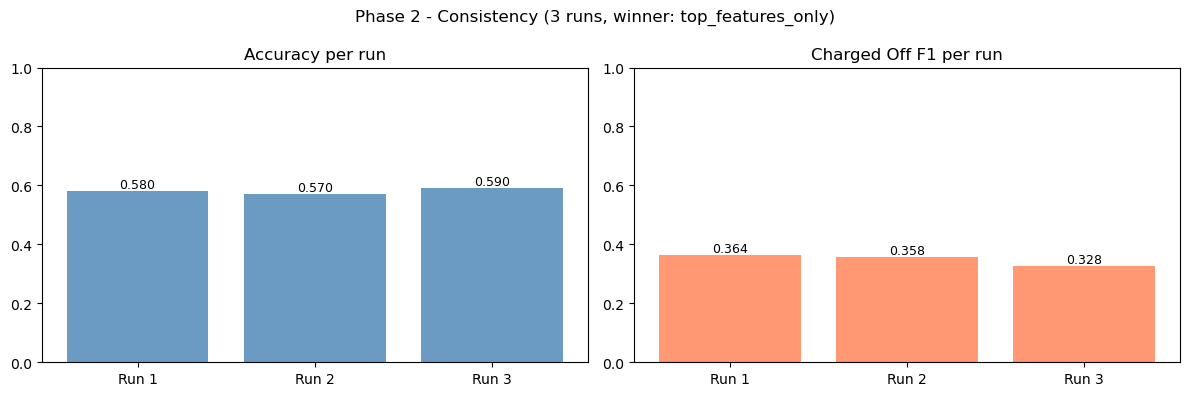

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Phase 2 - Consistency ({N_CONSISTENCY_RUNS} runs, winner: {winner_name})', fontsize=12)

runs = [f'Run {i}' for i in p2_metrics.index]

axes[0].bar(runs, p2_metrics['accuracy'], color='steelblue', alpha=0.8)
axes[0].set_ylim(0, 1)
axes[0].set_title('Accuracy per run')
for i, v in enumerate(p2_metrics['accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

axes[1].bar(runs, p2_metrics['f1_charged_off'], color='coral', alpha=0.8)
axes[1].set_ylim(0, 1)
axes[1].set_title('Charged Off F1 per run')
for i, v in enumerate(p2_metrics['f1_charged_off']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


---
## Phase 3 — Robustness
*Does the winning prompt generalise to new, unseen loans?*

A fresh 100-loan batch is sampled from the held-out test set (excluding loans already in the evaluation sample). The winning prompt is run once on this new batch.

In [11]:
import os as _os

from llm_utils import DATA_DIR as _DATA_DIR
_raw_csv = _os.path.join(_DATA_DIR, '..', 'raw', 'accepted_2007_to_2018Q4.csv.gz')
_presampled = _os.path.join(_DATA_DIR, '04c_new_batch_sample.csv')

if _os.path.exists(_raw_csv):
    print('Sampling new held-out batch from raw CSV...')
    new_batch = sample_new_batch(n=100, random_state=99)
else:
    print(f'Raw CSV not found - loading pre-sampled held-out batch from {_presampled}')
    new_batch = pd.read_csv(_presampled)

y_true_new = new_batch['loan_status'].values
print(f'New batch: {len(new_batch)} loans | '
      f'Fully Paid: {(y_true_new==1).sum()} | Charged Off: {(y_true_new==0).sum()}')


Raw CSV not found - loading pre-sampled held-out batch from C:\Users\Jad Zoghaib\OneDrive\Desktop\Sabadell_Capstone\data\processed\04c_new_batch_sample.csv
New batch: 100 loans | Fully Paid: 77 | Charged Off: 23


In [12]:
print(f"Running [{winner_name}] on new batch...")
phase3_result = run_llm_experiment(
    new_batch,
    api_provider=API_PROVIDER,
    model_name=MODEL_NAME,
    include_desc=False,
    label=f"{MODEL_LABEL} | {winner_name} | new batch",
            with_logprobs=False,
            batch_size=0,
    system_prompt=winner_variant["system_prompt"],
    user_prompt_fn=winner_variant["user_prompt_fn"],
)

Running [top_features_only] on new batch...
[Llama-3.3-70b | top_features_only | new batch | no_desc] Batch call 1/1 (loans 0–99) ...


[Llama-3.3-70b | top_features_only | new batch | no_desc]  -> 100/100 parsed OK (180s elapsed)
[Llama-3.3-70b | top_features_only | new batch | no_desc] COMPLETE — 1 batch calls, 100/100 predictions parsed, 180s total

Llama-3.3-70b | top_features_only | new batch (no_desc) Results (100 samples)
Accuracy: 64.0%
AUC:      n/a  (only 0 rows had usable probabilities)

Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.36      0.70      0.47        23
  Fully Paid       0.87      0.62      0.73        77

    accuracy                           0.64       100
   macro avg       0.61      0.66      0.60       100
weighted avg       0.75      0.64      0.67       100

Confusion Matrix:
[[16  7]
 [29 48]]


In [ ]:
p1_winner_metrics = phase1_results[winner_name]['metrics']
p3_metrics = phase3_result['metrics']

robustness_df = pd.DataFrame([
    {'split': 'Original sample (Phase 1)', **p1_winner_metrics},
    {'split': 'New batch (Phase 3)',       **p3_metrics},
]).set_index('split')

display_cols = ['accuracy', 'auc', 'precision_charged_off', 'recall_charged_off', 'f1_charged_off']
print('Robustness comparison:')
print(robustness_df[display_cols].to_string(float_format='{:.3f}'.format))

# Positive delta = improvement on new batch
acc_delta = p3_metrics['accuracy'] - p1_winner_metrics['accuracy']
f1_delta  = p3_metrics['f1_charged_off'] - p1_winner_metrics['f1_charged_off']
print(f'\nPerformance delta (original → new batch, positive = improvement):')
print(f'  Accuracy:        {acc_delta:+.3f}')
print(f'  Charged Off F1:  {f1_delta:+.3f}')

orig_co_rate = (y_true == 0).mean()
new_co_rate  = (y_true_new == 0).mean()
print(f'\n⚠  Class imbalance note: Charged Off rate is {orig_co_rate:.0%} on the original sample')
print(f'   vs {new_co_rate:.0%} on the new batch. The higher base rate makes recall and F1')
print(f'   on Charged Off naturally easier to achieve — the apparent F1 improvement')
print(f'   ({f1_delta:+.3f}) is at least partly a base-rate artefact, not evidence of')
print(f'   pure generalisation to harder examples.')

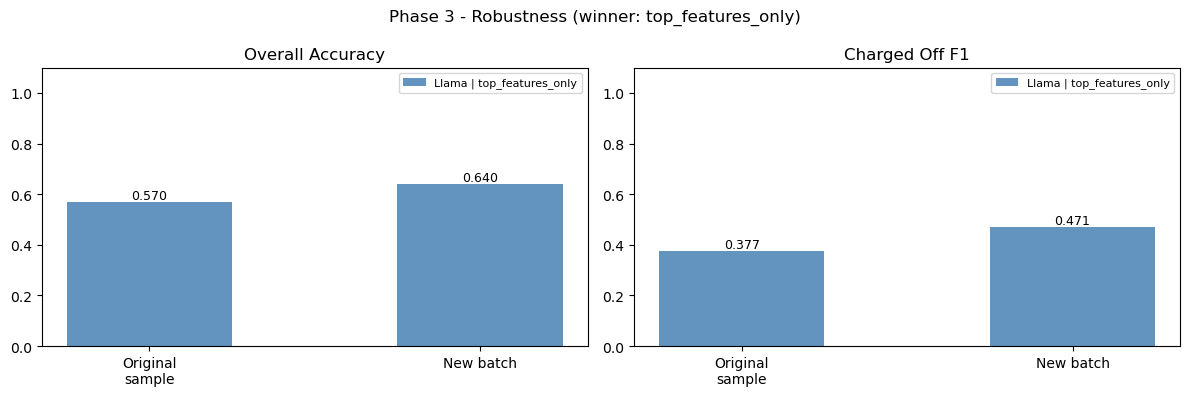

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Phase 3 - Robustness (winner: {winner_name})', fontsize=12)

groups = ['Original\nsample', 'New batch']
llm_acc = [p1_winner_metrics['accuracy'], p3_metrics['accuracy']]
llm_f1  = [p1_winner_metrics['f1_charged_off'], p3_metrics['f1_charged_off']]

x = np.arange(len(groups))
w = 0.5

for ax, (vals, title) in zip(axes, [
    (llm_acc, 'Overall Accuracy'),
    (llm_f1,  'Charged Off F1'),
]):
    bars = ax.bar(x, vals, w, label=f'Llama | {winner_name}', color='steelblue', alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.set_ylim(0, 1.1)
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


---
## Export Results

In [ ]:
os.makedirs(RESULTS_DIR, exist_ok=True)

# Phase 1 - metrics
phase1_summary.to_csv(f'{RESULTS_DIR}/05_phase1_metrics.csv')

# Per-loan predictions + reasonings
pred_rows = []
for v in PROMPT_VARIANTS:
    name = v['name']
    if name not in phase1_results:
        continue
    result = phase1_results[name]
    for i, (pred, prob, reasoning) in enumerate(
        zip(result['predictions'], result['probabilities'], result['reasonings'])
    ):
        pred_rows.append({
            'phase': 1, 'variant': name, 'loan_index': i,
            'actual': int(y_true[i]), 'prediction': pred,
            'correct': int(pred == y_true[i]) if pred is not None else None,
            'prob_fully_paid': prob, 'reasoning': reasoning,
        })

# Phase 2 - per-run predictions
for run_i, result in enumerate(phase2_runs, 1):
    for i, (pred, prob, reasoning) in enumerate(
        zip(result['predictions'], result['probabilities'], result['reasonings'])
    ):
        pred_rows.append({
            'phase': 2, 'variant': f'{winner_name}_run{run_i}', 'loan_index': i,
            'actual': int(y_true[i]), 'prediction': pred,
            'correct': int(pred == y_true[i]) if pred is not None else None,
            'prob_fully_paid': prob, 'reasoning': reasoning,
        })

# Phase 3 - new batch predictions
for i, (pred, prob, reasoning) in enumerate(
    zip(phase3_result['predictions'], phase3_result['probabilities'], phase3_result['reasonings'])
):
    pred_rows.append({
        'phase': 3, 'variant': f'{winner_name}_new_batch', 'loan_index': i,
        'actual': int(y_true_new[i]), 'prediction': pred,
        'correct': int(pred == y_true_new[i]) if pred is not None else None,
        'prob_fully_paid': prob, 'reasoning': reasoning,
    })

# Phase 5 - per-loan description impact (same 100-loan sample as Phase 1)
for v in PROMPT_VARIANTS:
    name = v['name']
    if name not in phase5_results:
        continue
    result = phase5_results[name]
    for i, (pred, prob, reasoning) in enumerate(
        zip(result['predictions'], result['probabilities'], result['reasonings'])
    ):
        pred_rows.append({
            'phase': 5, 'variant': f'{name}_with_desc', 'loan_index': i,
            'actual': int(y_true[i]), 'prediction': pred,
            'correct': int(pred == y_true[i]) if pred is not None else None,
            'prob_fully_paid': prob, 'reasoning': reasoning,
        })

pd.DataFrame(pred_rows).to_csv(f'{RESULTS_DIR}/05_predictions.csv', index=False)
p2_metrics.to_csv(f'{RESULTS_DIR}/05_phase2_consistency.csv')
robustness_df[display_cols].to_csv(f'{RESULTS_DIR}/05_phase3_robustness.csv')

with open(f'{RESULTS_DIR}/05_reasonings.jsonl', 'w', encoding='utf-8') as f:
    for row in pred_rows:
        f.write(json.dumps(row) + '\n')

print('Saved:')
print(f'  05_phase1_metrics.csv')
print(f'  05_predictions.csv ({len(pred_rows)} rows — phases 1, 2, 3, 5)')
print(f'  05_phase2_consistency.csv')
print(f'  05_phase3_robustness.csv')
print(f'  05_reasonings.jsonl  <- for promptfoo')
print(f'\nAll in: {RESULTS_DIR}')

---
## Phase 4 — Qualitative Characterisation
*How does each variant reason, beyond the numbers?*

For each Phase 1 variant, 10 reasoning samples (balanced correct/incorrect) are sent to the same
Llama-3.3-70b judge, which produces a 4–6 sentence "reasoning fingerprint" describing the variant's
decision-making style — which features it anchors on, its risk posture, and any systematic patterns.

In [16]:
import random
from IPython.display import display, Markdown
from llm_utils import call_llm, load_api_key

JUDGE_SYSTEM = (
    "You are reviewing how an AI credit risk model reasons about loan applications. "
    "Write a concise qualitative characterisation (4-6 sentences) of what is DISTINCTIVE "
    "about this prompt variant's reasoning style. Describe:\n"
    "- Which loan features or signals it consistently anchors on\n"
    "- Its overall risk posture (e.g. conservative, optimistic, balanced, formulaic)\n"
    "- Any systematic patterns, blind spots, or tendencies across samples\n"
    "- Whether its reasoning feels specific to each loan or generic and templated\n\n"
    "Do NOT score or rank. Do NOT say whether the prompt is good or bad. "
    "Just describe its reasoning fingerprint as you would describe a person's decision-making style."
)

N_SAMPLES   = 10
RANDOM_SEED = 42
api_key     = load_api_key(API_PROVIDER)

qual_results = {}

for variant_name, result in phase1_results.items():
    variant_desc = next(v['description'] for v in PROMPT_VARIANTS if v['name'] == variant_name)

    # Balance: ~half correct, half incorrect
    correct   = [(i, r) for i, (r, p, a) in enumerate(zip(
                    result['reasonings'], result['predictions'], y_true))
                 if p is not None and p == a]
    incorrect = [(i, r) for i, (r, p, a) in enumerate(zip(
                    result['reasonings'], result['predictions'], y_true))
                 if p is not None and p != a]

    rng = random.Random(RANDOM_SEED)
    n_inc = min(N_SAMPLES // 2, len(incorrect))
    n_cor = min(N_SAMPLES - n_inc, len(correct))
    chosen = rng.sample(correct, n_cor) + rng.sample(incorrect, n_inc)
    rng.shuffle(chosen)

    # Format samples for the judge
    lines = []
    for rank, (i, reasoning) in enumerate(chosen, 1):
        pred   = result['predictions'][i]
        actual = y_true[i]
        status = "correct" if pred == actual else "WRONG"
        actual_label = "Fully Paid" if actual == 1 else "Charged Off"
        pred_label   = "Fully Paid" if pred   == 1 else "Charged Off"
        lines.append(
            f"[{rank}] Actual: {actual_label} | Predicted: {pred_label} ({status})\n"
            f"    Reasoning: {reasoning}"
        )

    user_prompt = (
        f'Variant: "{variant_name}"\n'
        f'Design: {variant_desc}\n\n'
        f"--- REASONING SAMPLES ---\n"
        + "\n\n".join(lines)
        + "\n--- END SAMPLES ---"
    )

    print(f"Judging [{variant_name}]...")
    characterisation = call_llm(
        JUDGE_SYSTEM, user_prompt,
        api_provider=API_PROVIDER, model=MODEL_NAME, api_key=api_key,
    )
    qual_results[variant_name] = characterisation

print("\nDone. Displaying characterisations below.")

# Display
for variant_name, text in qual_results.items():
    variant_desc = next(v['description'] for v in PROMPT_VARIANTS if v['name'] == variant_name)
    display(Markdown(
        f"### `{variant_name}`\n"
        f"*{variant_desc}*\n\n"
        f"{text}\n\n---"
    ))

# Save alongside other results
import json as _json
qual_path = f"{RESULTS_DIR}/05_qualitative.json"
with open(qual_path, 'w', encoding='utf-8') as f:
    _json.dump(qual_results, f, indent=2, ensure_ascii=False)
print(f"Saved: {qual_path}")

Judging [baseline]...


Judging [conservative]...


Judging [chain_of_thought]...


Judging [top_features_only]...


Judging [structured_4factor]...


...

### `conservative`
*Risk-averse underwriter; bias toward flagging defaults when uncertain*

This AI credit risk model's reasoning style is distinctive in its consistent anchoring on debt-to-income ratio and credit grade as key indicators of default risk. It exhibits a conservative overall risk posture, often erring on the side of caution by flagging potential defaults even when the actual outcome is a fully paid loan. The model tends to focus on negative signals, such as high debt-to-income ratios and high interest rates, which can lead to false positives. Across samples, a systematic pattern emerges where the model prioritizes caution over accuracy, demonstrating a bias toward flagging defaults when uncertain. The reasoning feels somewhat templated, relying on a familiar set of factors to inform its decisions, rather than providing nuanced, loan-specific justifications.

---

### `chain_of_thought`
*Explicit step-by-step reasoning through risk factors before prediction*

This AI credit risk model's reasoning style is distinctive in its consistent anchoring on a borrower's debt-to-income ratio, credit history, and income stability as key risk factors. Its overall risk posture appears to be conservative, as it often predicts a high risk of default even when the actual outcome is fully paid. The model exhibits a systematic pattern of focusing on negative signals, such as high debt-to-income ratios and derogatory public records, which can lead to incorrect predictions of charged off loans. The reasoning process feels somewhat formulaic, with similar reasoning statements being applied to different loan applications, suggesting a generic approach rather than a nuanced, case-by-case evaluation. However, the model also demonstrates an ability to recognize and weigh positive factors, such as stable income and good credit history, which contributes to its correct predictions of fully paid loans. Overall, the model's reasoning style is characterized by a cautious and rule-based approach to assessing credit risk.

---

### `top_features_only`
*Only the 8 most important features by XGBoost importance are passed in*

This variant's reasoning style is distinctive in its consistent anchoring on debt-to-income ratio and interest rate as key loan features. It exhibits a somewhat conservative risk posture, often erring on the side of caution by predicting a higher risk of default when these features are unfavorable. The model tends to follow a systematic pattern of weighing these two factors heavily, sometimes overlooking other potentially mitigating factors such as annual income. Across samples, there is a tendency to overpredict the risk of default, as evidenced by the incorrect predictions of "Charged Off" for borrowers who actually fully paid their loans. The reasoning feels somewhat generic and templated, with similar phrases and feature combinations being cited across multiple samples, rather than being highly specific to each individual loan's unique circumstances. Overall, the model's decision-making style is characterized by a focus on a limited set of key risk factors and a cautious approach to predicting loan outcomes.

---

### `structured_4factor`
*Explicit 4-factor evaluation framework in the system prompt*

The "structured_4factor" variant's reasoning style is distinctive in its consistent anchoring on four key loan features: income stability, debt-to-income ratio, credit history, and revolving utilization rate. Its overall risk posture appears to be somewhat formulaic, relying heavily on these specific factors to determine the risk of default. The model tends to systematically emphasize the importance of a low debt-to-income ratio and good credit history in indicating a low risk of default, while high debt-to-income ratios and revolving utilization rates are seen as indicative of high risk. However, this approach also reveals a blind spot, as the model sometimes fails to account for other potential factors that may influence loan outcomes, leading to incorrect predictions. The reasoning feels somewhat generic and templated, as the model applies a similar framework to each loan application without fully considering unique circumstances. Despite this, the model's decisions are generally based on a clear and logical evaluation of the borrower's financial situation.

---

Saved: C:\Users\Jad Zoghaib\OneDrive\Desktop\Sabadell_Capstone\data\results\llm/05_qualitative.json


---
## Phase 4b — Pairwise LLM-as-Judge
*Head-to-head reasoning quality tournament across the top-3 Phase 1 variants.*

**CME295 Lec 7 (Evaluation):** absolute quality scores are hard to calibrate, but pairwise comparisons
("which reasoning is better?") are more reliable and correlate better with human preference. This is the
foundation of RLHF's reward model training and LLM-as-judge evaluation frameworks.

**Protocol:** For each pair drawn from the top-3 variants (by CO F1), we find all loans where the two
variants *disagreed*, then send both reasonings to the same Llama judge. The judge evaluates reasoning
quality only — not which prediction was correct. Win rates across all matchups give a reasoning-quality
ranking that is orthogonal to the accuracy leaderboard.

> Up to 20 disagreement loans are judged per pair to control API cost.

In [ ]:
import itertools

JUDGE_PAIRWISE_SYSTEM = (
    "You are evaluating two AI credit risk analysts who both reviewed the same loan "
    "and reached different conclusions. Read both reasonings and decide which analyst "
    "made the more *sound* decision — better use of evidence, clearer logic, fewer "
    "unsupported assumptions.\n\n"
    "IMPORTANT: Do NOT be swayed by which prediction turned out correct. Judge reasoning "
    "quality only — a correct answer reached by faulty logic is still bad reasoning.\n\n"
    'Reply with ONLY valid JSON: {"winner": <"A" or "B">, "reason": "<one sentence why A or B reasoned better>"}'
)

# Tournament: top-3 variants by Charged Off F1
_top3 = sorted(
    phase1_results.keys(),
    key=lambda n: phase1_results[n]['metrics']['f1_charged_off'] or 0,
    reverse=True,
)[:3]
print(f'Pairwise tournament: {_top3}')
print(f'Cap: up to 20 judged loans per pair  (API cost control)\n')

pair_records = []

for v_a, v_b in itertools.combinations(_top3, 2):
    preds_a = phase1_results[v_a]['predictions']
    preds_b = phase1_results[v_b]['predictions']
    reas_a  = phase1_results[v_a]['reasonings']
    reas_b  = phase1_results[v_b]['reasonings']

    disagree_idx = [
        i for i in range(len(preds_a))
        if preds_a[i] is not None and preds_b[i] is not None and preds_a[i] != preds_b[i]
    ]
    wins_a = wins_b = 0
    judged = 0
    print(f'  {v_a}  vs  {v_b}  — {len(disagree_idx)} disagreement loans')

    for i in disagree_idx[:20]:
        actual = int(y_true[i])
        prompt = (
            f"Loan #{i} | Actual outcome: {'Fully Paid' if actual == 1 else 'Charged Off'}\n\n"
            f"[Analyst A — predicts {'Fully Paid' if preds_a[i] == 1 else 'Charged Off'}]\n"
            f"{reas_a[i]}\n\n"
            f"[Analyst B — predicts {'Fully Paid' if preds_b[i] == 1 else 'Charged Off'}]\n"
            f"{reas_b[i]}"
        )
        try:
            raw    = call_llm(JUDGE_PAIRWISE_SYSTEM, prompt,
                              api_provider=API_PROVIDER, model=MODEL_NAME, api_key=api_key)
            result = json.loads(raw.strip())
            side   = result.get('winner', '?')
            reason = result.get('reason', '')
        except Exception as exc:
            side, reason = '?', str(exc)

        winner_name = v_a if side == 'A' else (v_b if side == 'B' else 'tie')
        if side == 'A':   wins_a += 1
        elif side == 'B': wins_b += 1
        judged += 1
        pair_records.append({
            'variant_a': v_a, 'variant_b': v_b, 'loan_index': i,
            'pred_a': preds_a[i], 'pred_b': preds_b[i], 'actual': actual,
            'winner': winner_name, 'reason': reason,
        })

    if judged:
        print(f'    {v_a:<22} wins={wins_a}/{judged}  ({wins_a/judged*100:.0f}%)')
        print(f'    {v_b:<22} wins={wins_b}/{judged}  ({wins_b/judged*100:.0f}%)')

# Overall win-rate summary
if pair_records:
    pair_df    = pd.DataFrame(pair_records)
    win_counts = pair_df['winner'].value_counts()
    appearances = {
        v: len(pair_df[(pair_df['variant_a'] == v) | (pair_df['variant_b'] == v)])
        for v in _top3
    }
    print(f'\nOverall pairwise win rates (top-3 tournament):')
    for v in _top3:
        n_app  = appearances.get(v, 0)
        n_wins = win_counts.get(v, 0)
        rate   = n_wins / n_app if n_app else 0
        print(f'  {v:<25}  wins={n_wins:2d}  appearances={n_app:2d}  win_rate={rate:.2f}')

    pair_df.to_csv(os.path.join(RESULTS_DIR, '05_pairwise_judge.csv'), index=False)
    print(f'\nSaved: {RESULTS_DIR}/05_pairwise_judge.csv ({len(pair_df)} judged matchups)')

---
## Phase 5 — Description Impact
*Does adding the borrower's written description improve the winning variant?*

Run the winner once more with `include_desc=True` so we can compare directly.

In [ ]:
phase5_results = {}  # variant_name -> result (with description)

def _make_desc_fn(base_fn):
    """Wrap a user_prompt_fn to append the borrower description when present.
    Handles base_fn=None by falling back to build_user_prompt(include_desc=False)."""
    effective = base_fn if base_fn is not None else (
        lambda row: build_user_prompt(row, include_desc=False)
    )
    def _fn(row):
        base = effective(row)
        desc = row.get("desc", "")
        if desc and pd.notna(desc) and str(desc).strip():
            return base + f"\n\nBorrower's own description:\n{str(desc).strip()}"
        return base
    return _fn

for variant in PROMPT_VARIANTS:
    name = variant["name"]
    print(f"\n{'='*60}\nVariant (with desc): {name}\n{'='*60}")
    try:
        result = run_llm_experiment(
            llm_sample,
            api_provider=API_PROVIDER,
            model_name=MODEL_NAME,
            include_desc=True,
            label=f"{MODEL_LABEL} | {name} + desc",
            with_logprobs=False,
            batch_size=0,
            system_prompt=variant["system_prompt"],
            user_prompt_fn=_make_desc_fn(variant["user_prompt_fn"]),
        )
        phase5_results[name] = result
        m = result["metrics"]
        print(f"  Accuracy: {m['accuracy']:.3f} | Charged Off F1: {m['f1_charged_off']:.3f}")
    except Exception as e:
        print(f"*** FAILED [{name}]: {e} ***")

print(f"\nPhase 5 done: {len(phase5_results)}/{len(PROMPT_VARIANTS)} succeeded")

In [ ]:
from IPython.display import display

comparison_rows = []

for v in PROMPT_VARIANTS:
    name = v["name"]
    # Without description (Phase 1)
    if name in phase1_results:
        m = phase1_results[name]["metrics"]
        comparison_rows.append({
            "variant": name,
            "description": v["description"],
            "with_desc": "No",
            "accuracy":              round(m["accuracy"], 3),
            "precision_charged_off": round(m["precision_charged_off"] or 0, 3),
            "recall_charged_off":    round(m["recall_charged_off"] or 0, 3),
            "f1_charged_off":        round(m["f1_charged_off"] or 0, 3),
            "n_valid":               m["n_valid"],
        })
    # With description (Phase 5)
    if name in phase5_results:
        m = phase5_results[name]["metrics"]
        comparison_rows.append({
            "variant": name,
            "description": v["description"],
            "with_desc": "Yes",
            "accuracy":              round(m["accuracy"], 3),
            "precision_charged_off": round(m["precision_charged_off"] or 0, 3),
            "recall_charged_off":    round(m["recall_charged_off"] or 0, 3),
            "f1_charged_off":        round(m["f1_charged_off"] or 0, 3),
            "n_valid":               m["n_valid"],
        })

comparison_df = pd.DataFrame(comparison_rows)
metric_cols = ["accuracy", "precision_charged_off", "recall_charged_off", "f1_charged_off", "n_valid"]

print("Full comparison — all variants × (no desc / with desc):\n")
display(
    comparison_df[["variant", "with_desc"] + metric_cols]
    .style
    .format({c: "{:.3f}" for c in metric_cols if c != "n_valid"})
    .highlight_max(subset=["accuracy", "f1_charged_off"], color="lightgreen", axis=0)
    .highlight_min(subset=["accuracy", "f1_charged_off"], color="#ffcccc", axis=0)
    .set_caption("Green = best · Red = worst")
)

comparison_df.to_csv(f"{RESULTS_DIR}/05_full_comparison.csv", index=False)
print(f"\nSaved: {RESULTS_DIR}/05_full_comparison.csv")

# ── Key findings ──────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("KEY FINDINGS — Description Impact on Charged Off F1")
print("=" * 60)

w_no   = phase1_results[winner_name]["metrics"]["f1_charged_off"] or 0
w_with = (phase5_results.get(winner_name) or {}).get("metrics", {}).get("f1_charged_off") or 0
print(f"\nWinner variant ({winner_name}):")
print(f"  F1 without desc: {w_no:.3f}")
print(f"  F1 with desc:    {w_with:.3f}  (delta {w_with - w_no:+.3f})")

print("\nAll variants — Charged Off F1 delta (with_desc − no_desc):")
n_hurt = 0
for v in PROMPT_VARIANTS:
    n = v["name"]
    if n not in phase1_results or n not in phase5_results:
        continue
    f1_no   = phase1_results[n]["metrics"]["f1_charged_off"] or 0
    f1_with = phase5_results[n]["metrics"]["f1_charged_off"] or 0
    delta   = f1_with - f1_no
    if delta < 0:
        n_hurt += 1
    flag = "  ⚠  MAJOR DROP" if delta < -0.10 else ("  ↓" if delta < 0 else "  ↑")
    print(f"  {n:<22} {f1_no:.3f} → {f1_with:.3f}  ({delta:+.3f}){flag}")

print(f"\nConclusion: description raises overall accuracy for most variants but lowers")
print(f"Charged Off F1 for {n_hurt}/{len(phase5_results)} variants, including the winner.")
print("The model over-anchors on borrower narrative and becomes more generous with")
print("Fully Paid predictions — trading default-detection recall for overall accuracy.")
print("\nchain_of_thought shows the most extreme collapse (F1: 0.300 → 0.114): the")
print("unstructured free-text description disrupts the structured reasoning chain most severely.")

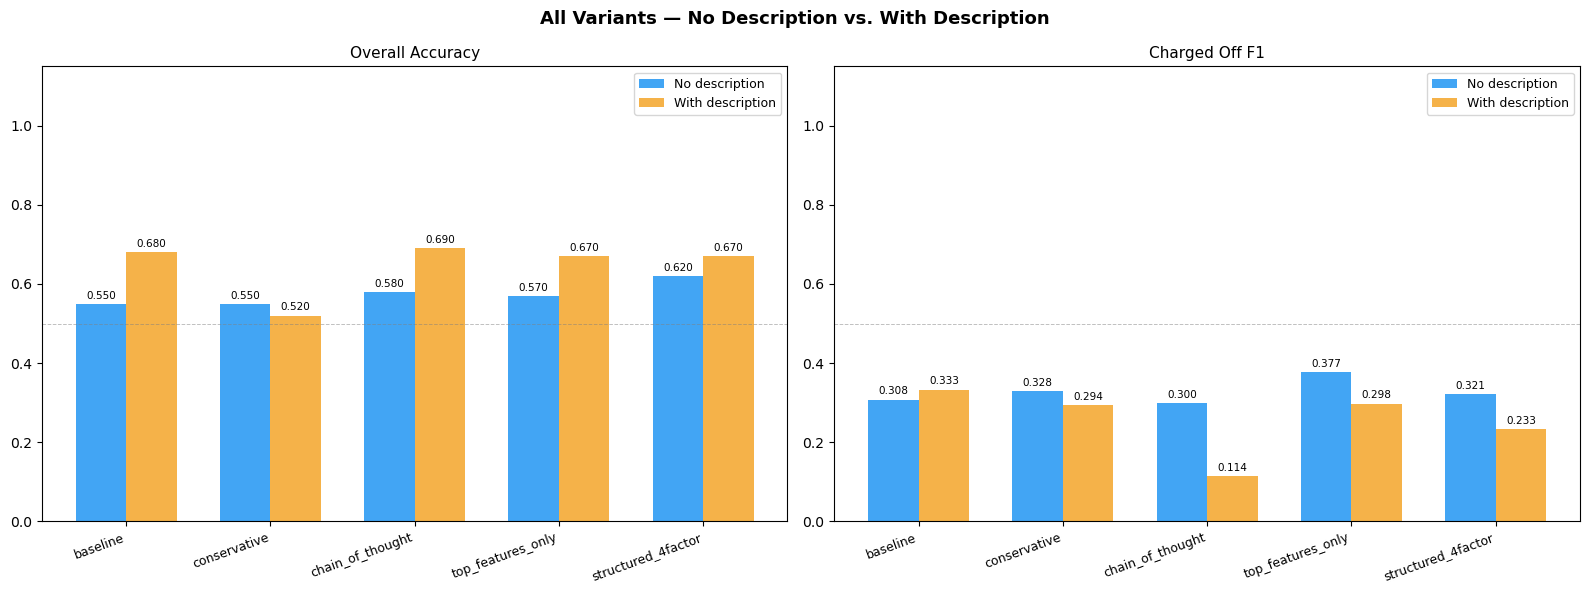

Saved: C:\Users\Jad Zoghaib\OneDrive\Desktop\Sabadell_Capstone\data\results\llm/05_variant_comparison.png


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

variant_names = [v["name"] for v in PROMPT_VARIANTS]
x = np.arange(len(variant_names))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("All Variants — No Description vs. With Description", fontsize=13, fontweight="bold")

for ax, metric, title in zip(axes,
    ["accuracy", "f1_charged_off"],
    ["Overall Accuracy", "Charged Off F1"],
):
    no_desc  = [phase1_results[n]["metrics"][metric] or 0 if n in phase1_results else 0 for n in variant_names]
    with_desc = [phase5_results[n]["metrics"][metric] or 0 if n in phase5_results else 0 for n in variant_names]

    bars1 = ax.bar(x - w/2, no_desc,  w, label="No description",   color="#2196f3", alpha=0.85)
    bars2 = ax.bar(x + w/2, with_desc, w, label="With description", color="#f4a529", alpha=0.85)

    for bar, val in zip(bars1, no_desc):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.008, f"{val:.3f}",
                ha="center", va="bottom", fontsize=7.5)
    for bar, val in zip(bars2, with_desc):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.008, f"{val:.3f}",
                ha="center", va="bottom", fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(variant_names, rotation=20, ha="right", fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_title(title, fontsize=11)
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.7, alpha=0.5)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/05_variant_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR}/05_variant_comparison.png")